# SOP return forecasting

In [1]:
# Runtime paths and output controls.
from pathlib import Path
import os

EXCEL_PATH = "agoyal_data.xlsx"
OUTPUT_DIR = "."
OUTPUT_SUFFIX = ""
TARGET_END = "2024-12-31"

# Public fallback key retained by request. Environment variable takes precedence.
PUBLIC_FRED_API_KEY = "99b6b648410a405f7a66d8117889ea0e"
FRED_API_KEY = os.getenv("FRED_API_KEY", PUBLIC_FRED_API_KEY)

# External data toggles.
USE_FRED_EXTENSION = True
USE_SHILLER_EXTENSION = True
USE_LOCAL_CACHE_FIRST = True
REQUEST_TIMEOUT_SECONDS = 10

# Forecast-model training controls.
FORECAST_START = "1948-01-31"
MIN_TRAIN_MONTHS = 240
SHRINKAGE_INTENSITY = 1200

# Portfolio construction controls.
ROLLING_VAR_WINDOW = 60
GAMMA_MARKOWITZ = 2.0
WEIGHT_BOUNDS = (0.0, 1.5)
VM_SCALE_BOUNDS = (0.25, 4.0)

# Fixed crisis definitions used by both forecast and portfolio views.
CRISIS_WINDOWS = {
    "Dot-com": ("2000-03-31", "2002-09-30"),
    "GFC": ("2007-12-31", "2009-06-30"),
    "COVID": ("2020-02-29", "2020-04-30"),
    "Inflation shock": ("2022-01-31", "2022-10-31"),
}

# Resolve base dir with a fallback for hosted notebook environments.
BASE_DIR = Path.cwd()
if not (BASE_DIR / EXCEL_PATH).exists() and Path("/mnt/data/agoyal_data.xlsx").exists():
    BASE_DIR = Path("/mnt/data")

OUT = BASE_DIR / OUTPUT_DIR
OUT.mkdir(parents=True, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Goyal workbook: {BASE_DIR / EXCEL_PATH}")
print(f"Output directory: {OUT}")
print(f"Target end: {TARGET_END}")
print(f"Forecast start: {FORECAST_START}")
print(f"FRED extension: {USE_FRED_EXTENSION}; Shiller extension: {USE_SHILLER_EXTENSION}; local cache first: {USE_LOCAL_CACHE_FIRST}")

Base directory: /Users/lucas/Code/SOP
Goyal workbook: /Users/lucas/Code/SOP/agoyal_data.xlsx
Output directory: /Users/lucas/Code/SOP
Target end: 2024-12-31
Forecast start: 1948-01-31
FRED extension: True; Shiller extension: True; local cache first: True


In [2]:
# Core scientific stack.
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional dependency for FRED API access.
try:
    import requests
except Exception:
    requests = None

# Optional dependency for p-values in inference tables.
try:
    from scipy import stats
except Exception:
    stats = None

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.6f}".format

In [3]:
# Core helpers for column/date normalization used across the notebook.
def clean_columns(cols):
    return [str(c).strip().lower() for c in cols]


def month_end(s):
    return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")


def infer_monthly_date_column(frame):
    out = frame.copy()
    out.columns = clean_columns(out.columns)
    if "date" not in out.columns:
        for c in ["yyyymm", "month", "mdate", "ym"]:
            if c in out.columns:
                out = out.rename(columns={c: "date"})
                break
    if "date" not in out.columns:
        raise KeyError("No date/yyyymm-like column found.")
    s = out["date"]
    if pd.api.types.is_numeric_dtype(s):
        sn = pd.to_numeric(s, errors="coerce")
        si = sn.round().astype("Int64")
        nn = si.dropna()
        if len(nn) and nn.between(180001, 220012).mean() > 0.80:
            parsed = pd.to_datetime(si.astype(str), format="%Y%m", errors="coerce")
        elif len(nn) and nn.between(1, 60000).mean() > 0.80:
            parsed = pd.to_datetime(sn, unit="D", origin="1899-12-30", errors="coerce")
        else:
            parsed = pd.to_datetime(s.astype(str), errors="coerce")
    else:
        parsed = pd.to_datetime(s, errors="coerce")
    out["date"] = parsed.dt.to_period("M").dt.to_timestamp("M")
    return out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)


def infer_annual_date_column(frame):
    out = frame.copy()
    out.columns = clean_columns(out.columns)
    if "year" not in out.columns:
        for c in ["yyyy", "date", "yr"]:
            if c in out.columns:
                out = out.rename(columns={c: "year"})
                break
    if "year" not in out.columns:
        raise KeyError("No year/yyyy-like column found.")
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    return out.dropna(subset=["year"]).sort_values("year").reset_index(drop=True)


def safe_log(x):
    x = pd.to_numeric(x, errors="coerce")
    return pd.Series(np.where(x > 0, np.log(x), np.nan), index=x.index)


def safe_log1p(x):
    x = pd.to_numeric(x, errors="coerce")
    return pd.Series(np.where(x > -1, np.log1p(x), np.nan), index=x.index)


def winsorize(s, lower=0.01, upper=0.99):
    s = pd.to_numeric(s, errors="coerce").copy()
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)


def compound_simple_return(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return (1 + x).prod() - 1 if len(x) else np.nan


def max_drawdown(returns):
    r = pd.Series(returns).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    return (wealth / peak - 1).min()


def add_suffix(name):
    p = Path(name)
    return p.with_name(f"{p.stem}{OUTPUT_SUFFIX}{p.suffix}")

In [4]:
# Forecast evaluation metrics used across benchmark and robustness tables.
def forecast_metrics(frame, forecast_col, y_col="ret_lead", benchmark_col="hist_mean", model_name=None):
    needed = [y_col, forecast_col, benchmark_col, "forecast_target_date"]
    use = frame[needed].dropna().copy()
    if len(use) == 0:
        return {
            "model": model_name or forecast_col,
            "N": 0,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
            "MSE": np.nan,
            "MSE_benchmark": np.nan,
            "OOS_R2_vs_HM": np.nan,
            "MAE": np.nan,
            "MAE_benchmark": np.nan,
            "MAE_gain": np.nan,
            "MSE_F": np.nan,
        }
    err = use[y_col] - use[forecast_col]
    berr = use[y_col] - use[benchmark_col]
    mse = (err ** 2).mean()
    bmse = (berr ** 2).mean()
    mae = err.abs().mean()
    bmae = berr.abs().mean()
    return {
        "model": model_name or forecast_col,
        "N": int(len(use)),
        "start_date": use["forecast_target_date"].min(),
        "end_date": use["forecast_target_date"].max(),
        "MSE": mse,
        "MSE_benchmark": bmse,
        "OOS_R2_vs_HM": 1 - mse / bmse if bmse > 0 else np.nan,
        "MAE": mae,
        "MAE_benchmark": bmae,
        "MAE_gain": bmae - mae,
        "MSE_F": len(use) * (bmse - mse) / mse if mse > 0 else np.nan,
    }


def connor_shrunk_univariate(frame, y_col, x_col, min_train=240, intensity=1200, start_idx=1):
    # Expanding-window univariate forecast with Connor-style slope shrinkage.
    y = pd.to_numeric(frame[y_col], errors="coerce").reset_index(drop=True)
    x = pd.to_numeric(frame[x_col], errors="coerce").reset_index(drop=True)
    pred = pd.Series(np.nan, index=frame.index, dtype=float)
    for i in range(start_idx, len(frame)):
        if pd.isna(x.iat[i]):
            continue
        mask = x.iloc[:i].notna() & y.iloc[:i].notna()
        n = int(mask.sum())
        if n < min_train:
            continue
        xtr = x.iloc[:i][mask].to_numpy(dtype=float)
        ytr = y.iloc[:i][mask].to_numpy(dtype=float)
        if np.nanstd(xtr) < 1e-14:
            pred.iat[i] = np.nanmean(ytr)
            continue
        X = np.column_stack([np.ones(n), xtr])
        beta = np.linalg.lstsq(X, ytr, rcond=None)[0]
        b_hat = beta[1]
        b_star = (n / (n + intensity)) * b_hat
        a_star = ytr.mean() - b_star * xtr.mean()
        pred.iat[i] = a_star + b_star * float(x.iat[i])
    return pred


def hac_se_mean(x, max_lag=None):
    # Newey-West style HAC standard error for the sample mean.
    x = pd.Series(x).dropna().to_numpy(dtype=float)
    n = len(x)
    if n < 3:
        return np.nan
    z = x - x.mean()
    if max_lag is None:
        max_lag = int(np.floor(4 * (n / 100) ** (2 / 9)))
    gamma0 = np.dot(z, z) / n
    var = gamma0
    for lag in range(1, max_lag + 1):
        cov = np.dot(z[lag:], z[:-lag]) / n
        weight = 1 - lag / (max_lag + 1)
        var += 2 * weight * cov
    return np.sqrt(max(var, 0) / n)


def dm_loss_test(frame, model_col, benchmark_model_col, y_col="ret_lead"):
    # Diebold-Mariano loss-difference test with HAC variance estimate.
    use = frame[[y_col, model_col, benchmark_model_col]].dropna()
    if len(use) < 5:
        return {
            "comparison": f"{model_col} vs {benchmark_model_col}",
            "N": int(len(use)),
            "mean_loss_diff": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan,
        }
    loss_model = (use[y_col] - use[model_col]) ** 2
    loss_benchmark = (use[y_col] - use[benchmark_model_col]) ** 2
    d = loss_benchmark - loss_model
    se = hac_se_mean(d)
    t = d.mean() / se if se and se > 0 else np.nan
    p = 2 * (1 - stats.t.cdf(abs(t), df=len(use) - 1)) if stats is not None and pd.notna(t) else np.nan
    return {
        "comparison": f"{model_col} vs {benchmark_model_col}",
        "N": int(len(use)),
        "mean_loss_diff": d.mean(),
        "t_stat": t,
        "p_value": p,
    }

## Data loading

The panel starts from the Goyal-Welch workbook. FRED columns are merged from the cached enriched file when available, then downloaded only if the cache is missing. Shiller extension code is retained for cases where the Goyal file does not reach the requested target date; in this uploaded dataset, Goyal already reaches 2024-12.

In [5]:
# External macro/market series pulled from FRED when not available in local cache.
FRED_SPECS = {
    "SP500": {"series_id": "SP500", "frequency": "m", "aggregation_method": "eop"},
    "CPIAUCSL": {"series_id": "CPIAUCSL", "frequency": "m", "aggregation_method": "avg"},
    "TB3MS": {"series_id": "TB3MS", "frequency": "m", "aggregation_method": "avg"},
    "VIXCLS": {"series_id": "VIXCLS", "frequency": "m", "aggregation_method": "eop"},
    "USREC": {"series_id": "USREC"},
}


def fred_observations(series_id, observation_start=None, observation_end=None, frequency=None, aggregation_method=None):
    if not USE_FRED_EXTENSION or not FRED_API_KEY or requests is None:
        return pd.DataFrame(columns=["date", series_id])
    params = {"series_id": series_id, "api_key": FRED_API_KEY, "file_type": "json"}
    if observation_start is not None:
        params["observation_start"] = pd.Timestamp(observation_start).date().isoformat()
    if observation_end is not None:
        params["observation_end"] = pd.Timestamp(observation_end).date().isoformat()
    if frequency is not None:
        params["frequency"] = frequency
    if aggregation_method is not None:
        params["aggregation_method"] = aggregation_method
    try:
        r = requests.get(
            "https://api.stlouisfed.org/fred/series/observations",
            params=params,
            timeout=REQUEST_TIMEOUT_SECONDS,
        )
        r.raise_for_status()
        payload = r.json().get("observations", [])
        if not payload:
            return pd.DataFrame(columns=["date", series_id])
        out = pd.DataFrame(payload)
        out["date"] = month_end(out["date"])
        out[series_id] = pd.to_numeric(out["value"].replace(".", np.nan), errors="coerce")
        return out[["date", series_id]].drop_duplicates("date")
    except Exception as exc:
        print(f"FRED download skipped/failed for {series_id}: {exc}")
        return pd.DataFrame(columns=["date", series_id])


def fetch_fred_bundle(start, end, missing_cols):
    # Download only the series currently missing from the local panel.
    frames = []
    for col in missing_cols:
        spec = FRED_SPECS[col]
        f = fred_observations(
            spec["series_id"],
            observation_start=start,
            observation_end=end,
            frequency=spec.get("frequency"),
            aggregation_method=spec.get("aggregation_method"),
        )
        if not f.empty:
            f = f.rename(columns={spec["series_id"]: col})
            frames.append(f)
    if not frames:
        return pd.DataFrame(columns=["date"] + missing_cols)
    out = frames[0]
    for f in frames[1:]:
        out = out.merge(f, on="date", how="outer")
    return out.sort_values("date").reset_index(drop=True)


def merge_fred_cache_or_download(monthly):
    # Prefer cached enriched panel, then backfill missing columns from live API.
    out = monthly.copy()
    external_cols = list(FRED_SPECS.keys())
    source_rows = []

    cache_path = BASE_DIR / "sop_monthly_enriched.csv"
    if USE_LOCAL_CACHE_FIRST and cache_path.exists():
        cache = pd.read_csv(cache_path, parse_dates=["date"])
        cache["date"] = month_end(cache["date"])
        cached_cols = [c for c in external_cols if c in cache.columns]
        if cached_cols:
            out = out.merge(cache[["date"] + cached_cols].drop_duplicates("date"), on="date", how="left")
            for c in cached_cols:
                source_rows.append({"variable": c, "source": "FRED cached in sop_monthly_enriched.csv", "non_null": int(out[c].notna().sum())})

    missing_cols = [c for c in external_cols if c not in out.columns or out[c].notna().sum() == 0]
    if missing_cols:
        fred = fetch_fred_bundle(out["date"].min(), max(out["date"].max(), pd.Timestamp(TARGET_END)), missing_cols)
        if not fred.empty:
            out = out.merge(fred, on="date", how="left", suffixes=("", "_fred_dl"))
            for c in missing_cols:
                dl = f"{c}_fred_dl"
                if dl in out.columns:
                    out[c] = out[c].combine_first(out[dl]) if c in out.columns else out[dl]
                    out = out.drop(columns=[dl])
                source_rows.append({"variable": c, "source": "FRED API", "non_null": int(out[c].notna().sum())})

    for c in external_cols:
        if c not in out.columns:
            out[c] = np.nan
            source_rows.append({"variable": c, "source": "missing", "non_null": 0})

    if "USREC" in out.columns:
        out["USREC"] = pd.to_numeric(out["USREC"], errors="coerce").fillna(0).astype(int)

    return out, pd.DataFrame(source_rows).drop_duplicates(["variable", "source"], keep="last")


def load_shiller_monthly_if_needed(current_end):
    # Shiller extension is only used if target date is beyond Goyal coverage.
    if not USE_SHILLER_EXTENSION or pd.Timestamp(current_end) >= pd.Timestamp(TARGET_END):
        return pd.DataFrame()
    local_candidates = [BASE_DIR / "IE Data.xls", BASE_DIR / "ie_data.xls", BASE_DIR / "ie_data.xlsx", BASE_DIR / "ie_data.csv"]
    urls = [
        "http://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/7fd201b2-28ad-476c-bc67-7a2cab5304a3/ie_data.xls?ver=1775144929611",
        "https://www.econ.yale.edu/~shiller/data/ie_data.csv",
        "https://www.econ.yale.edu/~shiller/data/ie_data.xlsx",
    ]
    sources = [p for p in local_candidates if p.exists()] + urls
    for src in sources:
        try:
            if str(src).lower().endswith(".csv"):
                raw = pd.read_csv(src, skiprows=7)
            else:
                raw = pd.read_excel(src, skiprows=7)
            cols = clean_columns(raw.columns)
            raw.columns = cols
            date_col = cols[0]
            out = raw.rename(columns={date_col: "date"}).copy()
            out["date"] = pd.to_numeric(out["date"], errors="coerce")
            out = out.dropna(subset=["date"])
            years = np.floor(out["date"]).astype(int)
            months = ((out["date"] - years) * 100).round().astype(int)
            months = months.clip(1, 12)
            out["date"] = pd.to_datetime(dict(year=years, month=months, day=1)).dt.to_period("M").dt.to_timestamp("M")
            rename = {}
            for c in out.columns:
                lc = str(c).lower()
                if lc in ["p", "price"]:
                    rename[c] = "price_shiller"
                elif lc in ["d", "dividend"]:
                    rename[c] = "dividend_shiller"
                elif lc in ["e", "earnings"]:
                    rename[c] = "earnings_shiller"
            out = out.rename(columns=rename)
            keep = ["date"] + [c for c in ["price_shiller", "dividend_shiller", "earnings_shiller"] if c in out.columns]
            return out[keep].drop_duplicates("date").sort_values("date")
        except Exception as exc:
            print(f"Shiller source skipped/failed ({src}): {exc}")
    return pd.DataFrame()

In [6]:
# eval_base placeholder (safe): attempt to define only if `df` exists

if 'df' in globals():

    eval_base = df[df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()

    print(f"eval_base (early) defined: {len(eval_base)} rows")

else:

    # df not defined yet; eval_base will be created later in the notebook

    pass

In [7]:
# Load and normalize monthly/annual Goyal-Welch sheets.
excel_path = BASE_DIR / EXCEL_PATH
if not excel_path.exists():
    raise FileNotFoundError(f"Could not find {excel_path}.")

monthly_raw = infer_monthly_date_column(pd.read_excel(excel_path, sheet_name="Monthly"))
annual_raw = infer_annual_date_column(pd.read_excel(excel_path, sheet_name="Annual"))

# Some workbook variants use `index` instead of `price`.
for raw in [monthly_raw, annual_raw]:
    if "price" not in raw.columns and "index" in raw.columns:
        raw.rename(columns={"index": "price"}, inplace=True)

# Harmonize slash-style names used in older sheets.
rename_map = {"d/p": "dp_gw", "d/y": "dy", "e/p": "ep", "d/e": "de", "b/m": "bm", "i/k": "ik"}
monthly_raw = monthly_raw.rename(columns=rename_map)
annual_raw = annual_raw.rename(columns=rename_map)

required = ["date", "price", "d12", "e12", "ret"]
missing = [c for c in required if c not in monthly_raw.columns]
if missing:
    raise KeyError(f"Missing required Goyal columns: {missing}")

# Keep the benchmark predictor set clean and explicit.
clean_predictors = ["dfy", "tbl", "tms", "ntis", "infl", "ltr", "dfr", "svar", "dp_gw", "dy", "ep", "de", "bm", "cay"]
base_cols = ["date", "price", "d12", "e12", "ret", "retx", "rfree", "lty"] + clean_predictors
monthly = monthly_raw[[c for c in base_cols if c in monthly_raw.columns]].copy()
for c in monthly.columns:
    if c != "date":
        monthly[c] = pd.to_numeric(monthly[c], errors="coerce")

monthly, fred_source_audit = merge_fred_cache_or_download(monthly)
shiller_extra = load_shiller_monthly_if_needed(monthly["date"].max())

# Persist a source audit table for reproducibility.
source_audit = pd.DataFrame([
    {"variable": "price, d12, e12, ret, retx, rfree, Goyal predictors", "source": "Amit Goyal-Welch workbook", "non_null": len(monthly)},
    {"variable": "Shiller price/dividend/earnings extension", "source": "Robert Shiller data", "non_null": int(len(shiller_extra))},
])
source_audit = pd.concat([source_audit, fred_source_audit], ignore_index=True)
source_audit.to_csv(OUT / add_suffix("sop_data_source_audit.csv"), index=False)

display(source_audit)
print(f"Monthly Goyal rows: {len(monthly_raw):,} from {monthly_raw['date'].min().date()} to {monthly_raw['date'].max().date()}")
print(f"Annual Goyal rows:  {len(annual_raw):,} from {int(annual_raw['year'].min())} to {int(annual_raw['year'].max())}")

,variable,source,non_null
0,"price, d12, e12, ret, retx, rfree, Goyal predi...",Amit Goyal-Welch workbook,1848
1,Shiller price/dividend/earnings extension,Robert Shiller data,0
2,SP500,FRED cached in sop_monthly_enriched.csv,104
3,CPIAUCSL,FRED cached in sop_monthly_enriched.csv,936
4,TB3MS,FRED cached in sop_monthly_enriched.csv,1092
5,VIXCLS,FRED cached in sop_monthly_enriched.csv,420
6,USREC,FRED cached in sop_monthly_enriched.csv,1848


Monthly Goyal rows: 1,848 from 1871-01-31 to 2024-12-31
Annual Goyal rows:  154 from 1871 to 2024


## SOP components and single benchmark construction

The historical mean is computed once on the full monthly panel as the expanding mean of realized log returns through date `t`. It is never recomputed inside VIX, crisis, or strategy subsets.

In [8]:
# Build the canonical monthly panel used by all downstream sections.
df = monthly.sort_values("date").reset_index(drop=True).copy()

for c in ["price", "d12", "e12", "ret", "rfree", "tbl"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Goyal `ret` and `rfree` are monthly simple returns in decimal form.
df["ret_decimal"] = df["ret"]
df["r_log"] = safe_log1p(df["ret_decimal"])
df["rf_simple"] = pd.to_numeric(df.get("rfree"), errors="coerce") if "rfree" in df.columns else np.nan

# Convert T-bill conventions to monthly decimal forecast rate.
if "tbl" in df.columns:
    tbl = pd.to_numeric(df["tbl"], errors="coerce")
    df["rf_forecast_simple"] = (tbl / 12).where(tbl.abs() < 1, tbl / 1200)
else:
    df["rf_forecast_simple"] = df["rf_simple"]

# SOP decomposition terms.
pe = df["price"] / df["e12"].replace(0, np.nan)
df["dp"] = safe_log1p(df["d12"] / (12 * df["price"]))
df["ge"] = safe_log(df["e12"] / df["e12"].shift(1))
df["gm"] = safe_log(pe / pe.shift(1))
df["gs"] = df["ge"].rolling(MIN_TRAIN_MONTHS, min_periods=MIN_TRAIN_MONTHS).mean()
df["ms"] = df["gs"] + df["dp"]

# Forecast timing convention: row t predicts row t+1.
df["forecast_target_date"] = df["date"].shift(-1)
df["ret_lead"] = df["r_log"].shift(-1)
df["rf_log"] = safe_log1p(df["rf_simple"])
df["rf_log_next"] = df["rf_log"].shift(-1)
df["rf_simple_next"] = df["rf_simple"].shift(-1)
df["xret_lead"] = df["ret_lead"] - df["rf_log_next"]

# Historical-mean benchmark is fixed once on the full panel.
df["hist_mean"] = df["r_log"].expanding(min_periods=MIN_TRAIN_MONTHS).mean()
df["hist_mean_xret"] = (df["r_log"] - df["rf_log"]).expanding(min_periods=MIN_TRAIN_MONTHS).mean()

# Robustness variants: lagged fundamentals.
df["d12_lag1"] = df["d12"].shift(1)
df["e12_lag1"] = df["e12"].shift(1)
pe_lagfund = df["price"] / df["e12_lag1"].replace(0, np.nan)
df["dp_lagfund"] = safe_log1p(df["d12_lag1"] / (12 * df["price"]))
df["ge_lagfund"] = safe_log(df["e12_lag1"] / df["e12_lag1"].shift(1))
df["gm_lagfund"] = safe_log(pe_lagfund / pe_lagfund.shift(1))
df["gs_lagfund"] = df["ge_lagfund"].rolling(MIN_TRAIN_MONTHS, min_periods=MIN_TRAIN_MONTHS).mean()
df["ms_lagfund"] = df["gs_lagfund"] + df["dp_lagfund"]

# Robustness variants: winsorized components.
df["ge_winsor"] = winsorize(df["ge"], 0.01, 0.99)
df["gm_winsor"] = winsorize(df["gm"], 0.01, 0.99)
df["gs_winsor"] = df["ge_winsor"].rolling(MIN_TRAIN_MONTHS, min_periods=MIN_TRAIN_MONTHS).mean()
df["ms_winsor"] = df["gs_winsor"] + df["dp"]

if "VIXCLS" in df.columns:
    df["VIXCLS_lag1"] = df["VIXCLS"].shift(1)
else:
    df["VIXCLS"] = np.nan
    df["VIXCLS_lag1"] = np.nan

component_sum = df["dp"] + df["ge"] + df["gm"]
df["decomp_error"] = df["r_log"] - component_sum

monthly_path = OUT / add_suffix("sop_monthly_enriched.csv")
df.to_csv(monthly_path, index=False)

hist_check = df.loc[df["hist_mean"].notna(), ["date", "hist_mean"]].head()
print(f"Saved monthly fixed panel: {monthly_path}")
print(f"Monthly panel shape: {df.shape}")
print(f"First non-null full-panel historical means:")
display(hist_check)

Saved monthly fixed panel: /Users/lucas/Code/SOP/sop_monthly_enriched.csv
Monthly panel shape: (1848, 57)
First non-null full-panel historical means:


,date,hist_mean
899,1945-12-31,0.005102
900,1946-01-31,0.005360
901,1946-02-28,0.005059
902,1946-03-31,0.005235
903,1946-04-30,0.005358


In [9]:
# Descriptive statistics table with raw count/skew/kurt values (no percent scaling).
stat_vars = ["r_log", "dp", "ge", "gm", "gs", "ms", "hist_mean", "VIXCLS", "dfy", "ntis", "tbl", "tms"]
stat_vars = [v for v in stat_vars if v in df.columns]

stats_rows = []
for v in stat_vars:
    s = pd.to_numeric(df[v], errors="coerce").dropna()
    stats_rows.append({
        "variable": v,
        "count": int(s.count()),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p25": s.quantile(0.25),
        "median": s.median(),
        "p75": s.quantile(0.75),
        "max": s.max(),
        "skew": s.skew(),
        "kurt": s.kurt(),
    })

desc_stats = pd.DataFrame(stats_rows)
desc_stats.to_csv(OUT / add_suffix("sop_descriptive_stats.csv"), index=False)
display(desc_stats)

,variable,count,mean,std,min,p25,median,p75,max,skew,kurt
0,r_log,1188,0.008152,0.053676,-0.338921,-0.016972,0.013076,0.038189,0.346643,-0.481913,7.663306
1,dp,1848,0.003526,0.001471,0.000904,0.002510,0.003504,0.004438,0.012721,0.570889,1.307467
2,ge,1847,0.003392,0.036848,-0.528281,-0.008757,0.005479,0.016208,0.703855,1.904543,114.377726
3,gm,1847,0.000501,0.057400,-0.723815,-0.025612,0.000906,0.028071,0.536072,-0.531330,23.861632
4,gs,1608,0.003443,0.002673,-0.005382,0.001704,0.004039,0.005421,0.008672,-0.649149,-0.288059
5,ms,1608,0.006800,0.002561,-0.002787,0.005522,0.006903,0.008395,0.014329,-0.294076,0.410407
6,hist_mean,949,0.007441,0.000904,0.004118,0.007207,0.007716,0.007952,0.008779,-1.878417,3.593005
7,VIXCLS,420,19.538905,7.503524,9.510000,13.757500,17.665000,23.505000,59.890000,1.708700,4.471878
8,dfy,1272,0.011660,0.006834,0.003200,0.007100,0.009400,0.014100,0.056400,2.204194,7.515247
9,ntis,1177,0.015331,0.025841,-0.055954,0.002195,0.015588,0.026702,0.177041,1.613389,7.725082


## Forecast evaluation

These tables evaluate forecasts only. Portfolio returns are handled later in a separate section.

# The annual, non-overlapping SOP evaluation was removed. 
# It produced misleading timing and adds little value compared with the monthly results.


In [10]:

def build_pred_table(work_df, model_cols, base_mask, label):
    rows = [forecast_metrics(work_df[base_mask], "ms", model_name="SOP baseline")]
    for p in model_cols:
        rows.append(
            forecast_metrics(
                work_df[base_mask],
                f"fc_{p}",
                model_name=p,
            )
        )
    out = pd.DataFrame(rows).sort_values("OOS_R2_vs_HM", ascending=False).reset_index(drop=True)
    out["sample_type"] = label
    return out

# Excludes USREC/non-real-time variables, FRED duplicates, outcome variables (ret/retx), and short specialized add-ons.
BENCHMARK_PREDICTORS = ["dfy", "tbl", "tms", "ntis", "infl", "ltr", "dfr", "svar", "dp_gw", "dy", "ep", "de", "bm"]
BENCHMARK_PREDICTORS = [p for p in BENCHMARK_PREDICTORS if p in df.columns]

bench_df = df.copy()
for p in BENCHMARK_PREDICTORS:
    bench_df[f"fc_{p}"] = connor_shrunk_univariate(bench_df, "ret_lead", p, MIN_TRAIN_MONTHS, SHRINKAGE_INTENSITY)

base_mask = bench_df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)
sample_fraction = {}
for p in BENCHMARK_PREDICTORS:
    n_p = int(bench_df.loc[base_mask, ["ret_lead", "hist_mean", f"fc_{p}"]].dropna().shape[0])
    n_sop = int(bench_df.loc[base_mask, ["ret_lead", "hist_mean", "ms"]].dropna().shape[0])
    sample_fraction[p] = (n_p / n_sop) if n_sop > 0 else 0.0

full_sample_predictors = [p for p in BENCHMARK_PREDICTORS if sample_fraction.get(p, 0.0) >= 0.90]
available_sample_predictors = [p for p in BENCHMARK_PREDICTORS if p not in full_sample_predictors]

bench_full = build_pred_table(bench_df, full_sample_predictors, base_mask, "full_sample")
bench_avail = build_pred_table(bench_df, available_sample_predictors, base_mask, "available_sample")

bench_full.to_csv(OUT / add_suffix("sop_benchmark_full_sample.csv"), index=False)
bench_avail.to_csv(OUT / add_suffix("sop_benchmark_available_sample.csv"), index=False)

# Keep legacy combined output too for compatibility.
bench_table = pd.concat([bench_full, bench_avail], ignore_index=True)
bench_table.to_csv(OUT / add_suffix("sop_benchmark_results.csv"), index=False)

display(bench_full[["model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain", "MSE_F"]])
display(bench_avail[["model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain", "MSE_F"]])

,model,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain,MSE_F
0,SOP baseline,924,1948-01-31,2024-12-31,0.005767,0.000025,5.359241
1,ep,924,1948-01-31,2024-12-31,0.002687,-0.000099,2.489425
2,dy,924,1948-01-31,2024-12-31,0.000456,-0.000179,0.421680
3,dp_gw,924,1948-01-31,2024-12-31,0.000421,-0.000112,0.388873
4,infl,924,1948-01-31,2024-12-31,0.000334,0.000026,0.308945
5,ntis,924,1948-01-31,2024-12-31,0.000241,0.000119,0.222829
6,bm,924,1948-01-31,2024-12-31,-0.000138,-0.000213,-0.127837
7,dfy,924,1948-01-31,2024-12-31,-0.000362,-0.000013,-0.334395
8,ltr,924,1948-01-31,2024-12-31,-0.000396,-0.000049,-0.365630
9,tms,924,1948-01-31,2024-12-31,-0.000636,0.000008,-0.587712


,model,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain,MSE_F
0,SOP baseline,924,1948-01-31,2024-12-31,0.005767,0.000025,5.359241


## VIX-enhanced SOP on a common sample

The VIX comparison is built on one common row set. Baseline SOP, VIX-enhanced SOP, DFY-enhanced SOP, and NTIS-enhanced SOP all use the same `ret_lead`, the same full-panel `hist_mean`, and the same dates.

In [11]:
# VIX-enhanced SOP: replace the gm component with a VIX-forecasted version
# This tests whether conditioning on vol regime improves return prediction
vix_df = bench_df.copy()
vix_df["gm_lead"] = vix_df["gm"].shift(-1)  # gm we want to predict is the future realized gm

# Predictors to compare against VIX for forecasting gm
# VIXCLS = CBOE VIX, dfy = default spread, ntis = net equity issuance, tbl = T-bill rate, tms = term spread
VIX_COMPARE = ["VIXCLS", "dfy", "ntis", "tbl", "tms"]
VIX_COMPARE = [p for p in VIX_COMPARE if p in vix_df.columns]

# Build enhanced SOP forecasts using each predictor to forecast gm
# For each predictor p: gm_forecast = Connorshrink(gm_lead ~ p)
# Then ms_enh = gs + dp + gm_forecast (replacing the actual gm with forecasted)
for p in VIX_COMPARE:
    vix_df[f"gm_fc_{p}"] = connor_shrunk_univariate(vix_df, "gm_lead", p, MIN_TRAIN_MONTHS, SHRINKAGE_INTENSITY)
    vix_df[f"ms_enh_{p}"] = vix_df["gs"] + vix_df["dp"] + vix_df[f"gm_fc_{p}"]

# Also compute VIX-lagged version for robustness (avoids contemporaneous VIX)
# Uses VIX from t-1 instead of VIX from t to ensure real-time implementability
vix_df["gm_fc_VIX_lag1"] = connor_shrunk_univariate(vix_df, "gm_lead", "VIXCLS_lag1", MIN_TRAIN_MONTHS, SHRINKAGE_INTENSITY)
vix_df["ms_enh_VIX_lag1"] = vix_df["gs"] + vix_df["dp"] + vix_df["gm_fc_VIX_lag1"]

# Build common sample for fair comparison across all enhanced models
# Drop any row missing required columns to ensure all models have same data
common_required = ["ret_lead", "hist_mean", "ms", "forecast_target_date"] + [
    f"ms_enh_{p}" for p in ["VIXCLS", "dfy", "ntis"] if f"ms_enh_{p}" in vix_df.columns
]
# Start from 1990-01-31 when VIX data becomes available
vix_common = vix_df[vix_df["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=common_required).copy()

# Evaluate each enhanced model vs baseline SOP
vix_rows = [forecast_metrics(vix_common, "ms", model_name="Baseline SOP")]
for p in VIX_COMPARE:
    col = f"ms_enh_{p}"
    if col in vix_common.columns:
        m = forecast_metrics(vix_common, col, model_name=f"Enhanced SOP: {p}")
        # Also compute R2 vs baseline SOP (not just historical mean benchmark)
        mse_model = ((vix_common["ret_lead"] - vix_common[col]) ** 2).mean()
        mse_base = ((vix_common["ret_lead"] - vix_common["ms"]) ** 2).mean()
        m["R2_vs_baseline_SOP"] = 1 - mse_model / mse_base if mse_base > 0 else np.nan
        vix_rows.append(m)

vix_common_table = pd.DataFrame(vix_rows).sort_values("OOS_R2_vs_HM", ascending=False).reset_index(drop=True)
vix_common_table.to_csv(OUT / add_suffix("sop_vix_common_results.csv"), index=False)
vix_df.to_csv(OUT / add_suffix("sop_vix_common_forecasts.csv"), index=False)

display(vix_common_table[["model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "R2_vs_baseline_SOP", "MAE_gain"]])
print(f"Common VIX comparison sample: N={len(vix_common)}, {vix_common['forecast_target_date'].min().date()} to {vix_common['forecast_target_date'].max().date()}")

,model,N,start_date,end_date,OOS_R2_vs_HM,R2_vs_baseline_SOP,MAE_gain
0,Enhanced SOP: VIXCLS,179,2010-02-28,2024-12-31,0.013373,0.022818,-0.000076
1,Enhanced SOP: ntis,179,2010-02-28,2024-12-31,0.001160,0.010722,0.000327
2,Enhanced SOP: tms,179,2010-02-28,2024-12-31,-0.005061,0.004561,-0.000036
3,Enhanced SOP: dfy,179,2010-02-28,2024-12-31,-0.008223,0.001429,-0.000408
4,Enhanced SOP: tbl,179,2010-02-28,2024-12-31,-0.008233,0.001419,-0.000163
5,Baseline SOP,179,2010-02-28,2024-12-31,-0.009666,NaN,-0.000225


Common VIX comparison sample: N=179, 2010-02-28 to 2024-12-31


In [12]:
# Diebold-Mariano test: compare VIX-enhanced SOP vs each alternative enhanced SOP
# Tests whether VIX enhancement provides statistically significant forecast improvement
# H0: Both forecasts have equal loss (typically squared error)
dm_rows = []
if "ms_enh_VIXCLS" in vix_common.columns:
    for p in ["dfy", "ntis", "tbl", "tms"]:
        col = f"ms_enh_{p}"
        if col in vix_common.columns:
            # Compare VIX-enhanced vs each alternative using DM test with HAC standard errors
            dm_rows.append(dm_loss_test(vix_common, "ms_enh_VIXCLS", col))

dm_table = pd.DataFrame(dm_rows)
dm_table.to_csv(OUT / add_suffix("sop_vix_dm_tests.csv"), index=False)
display(dm_table)

,comparison,N,mean_loss_diff,t_stat,p_value
0,ms_enh_VIXCLS vs ms_enh_dfy,179,0.000038,1.275812,0.203684
1,ms_enh_VIXCLS vs ms_enh_ntis,179,0.000022,0.719337,0.472877
2,ms_enh_VIXCLS vs ms_enh_tbl,179,0.000038,1.228887,0.220736
3,ms_enh_VIXCLS vs ms_enh_tms,179,0.000033,1.095132,0.274938


In [13]:
# Two-stage mean-reversion forecast model
# Hypothesis: valuation ratios (e.g., log PE) revert to fair value driven by macro predictors
# Stage 1: Regress level (e.g., log PE) on predictor to get "fair value"
# Stage 2: Regress the residual (actual - fair) on target (future gm) with shrinkage
# Final forecast = intercept + slope * (current level - fair value)
def two_stage_reversion_forecast(frame, level_col, predictor_col, target_col, min_train=240, intensity=1200):
    level = pd.to_numeric(frame[level_col], errors="coerce").reset_index(drop=True)
    predx = pd.to_numeric(frame[predictor_col], errors="coerce").reset_index(drop=True)
    target = pd.to_numeric(frame[target_col], errors="coerce").reset_index(drop=True)
    out = pd.Series(np.nan, index=frame.index, dtype=float)
    for i in range(1, len(frame)):
        # Stage 1: fit fair value model using data through t-1
        m1 = level.iloc[:i].notna() & predx.iloc[:i].notna()
        if m1.sum() < min_train or pd.isna(predx.iat[i]) or pd.isna(level.iat[i]):
            continue
        x1 = predx.iloc[:i][m1].to_numpy(dtype=float)
        y1 = level.iloc[:i][m1].to_numpy(dtype=float)
        X1 = np.column_stack([np.ones(len(x1)), x1])
        b = np.linalg.lstsq(X1, y1, rcond=None)[0]
        fair_i = b[0] + b[1] * predx.iat[i]  # fair value at time i
        res_i = level.iat[i] - fair_i  # deviation from fair value
        
        # Compute fair values for historical period for residual calculation
        fair_prev = pd.Series(np.nan, index=range(i), dtype=float)
        fair_prev.loc[m1[m1].index] = b[0] + b[1] * predx.iloc[:i][m1]
        resid_prev = level.iloc[:i] - fair_prev  # historical residuals
        
        # Stage 2: fit reversion model (residual ~ target) with shrinkage
        m2 = resid_prev.notna() & target.iloc[:i].notna()
        if m2.sum() < min_train:
            continue
        x2 = resid_prev[m2].to_numpy(dtype=float)
        y2 = target.iloc[:i][m2].to_numpy(dtype=float)
        if np.std(x2) < 1e-14:
            out.iat[i] = np.nanmean(y2)
            continue
        X2 = np.column_stack([np.ones(len(x2)), x2])
        beta = np.linalg.lstsq(X2, y2, rcond=None)[0]
        slope = (len(x2) / (len(x2) + intensity)) * beta[1]  # shrunk slope
        intercept = y2.mean() - slope * x2.mean()
        out.iat[i] = intercept + slope * res_i
    return out

# Apply reversion model using log PE as the level variable
rev_df = vix_df.copy()
rev_df["pe_log"] = safe_log(rev_df["price"] / rev_df["e12"].replace(0, np.nan))

# Build reversion-based gm forecasts for each predictor
for p in ["VIXCLS", "dfy", "ntis"]:
    if p in rev_df.columns:
        rev_df[f"gm_rev_{p}"] = two_stage_reversion_forecast(rev_df, "pe_log", p, "gm_lead", MIN_TRAIN_MONTHS, SHRINKAGE_INTENSITY)
        rev_df[f"ms_rev_{p}"] = rev_df["gs"] + rev_df["dp"] + rev_df[f"gm_rev_{p}"]

# Evaluate reversion models on common sample (1990 onwards)
rev_required = ["ret_lead", "hist_mean", "ms"] + [f"ms_rev_{p}" for p in ["VIXCLS", "dfy", "ntis"] if f"ms_rev_{p}" in rev_df.columns]
rev_common = rev_df[rev_df["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=rev_required).copy()

rev_rows = [forecast_metrics(rev_common, "ms", model_name="Baseline SOP")]
for p in ["VIXCLS", "dfy", "ntis"]:
    col = f"ms_rev_{p}"
    if col in rev_common.columns:
        rev_rows.append(forecast_metrics(rev_common, col, model_name=f"Reversion SOP: {p}"))

rev_table = pd.DataFrame(rev_rows).sort_values("OOS_R2_vs_HM", ascending=False).reset_index(drop=True)
rev_table.to_csv(OUT / add_suffix("sop_reversion_results.csv"), index=False)

display(rev_table[["model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain"]])

from IPython.display import Markdown, display as _display_markdown
_display_markdown(
    Markdown(
        "**Note - exploratory reversion extension.** The VIX reversion extension is exploratory. "
        "Because the reversion residual appears non-stationary in some tests, we do not treat this model "
        "as reliable evidence of improved predictability and report it only for completeness."
    )
)

,model,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain
0,Reversion SOP: VIXCLS,179,2010-02-28,2024-12-31,0.002472,0.000032
1,Baseline SOP,179,2010-02-28,2024-12-31,-0.009666,-0.000225
2,Reversion SOP: dfy,179,2010-02-28,2024-12-31,-0.015967,-0.000444
3,Reversion SOP: ntis,179,2010-02-28,2024-12-31,-0.017863,-0.000512


**Note - exploratory reversion extension.** The VIX reversion extension is exploratory. Because the reversion residual appears non-stationary in some tests, we do not treat this model as reliable evidence of improved predictability and report it only for completeness.

## Crisis forecast performance

Fixed windows use forecast target months. The dynamic VIX rule is ex ante: a target month is reached from a forecast date whose month-end VIX is above 25.

In [14]:
# Label forecast target dates with predefined crisis windows
def fixed_crisis_label(ts):
    if pd.isna(ts):
        return None
    for label, (start, end) in CRISIS_WINDOWS.items():
        if pd.Timestamp(start) <= ts <= pd.Timestamp(end):
            return label
    return None

# Build crisis classification using two definitions:
# 1. Fixed windows: predetermined date ranges for major crises
#    - Dot-com: 2000-03 to 2002-09
#    - GFC: 2007-12 to 2009-06
#    - COVID: 2020-02 to 2020-04
#    - Inflation shock: 2022-01 to 2022-10
# 2. VIX>25: ex-ante rule - target month reached from forecast date with VIX > 25
crisis_df = vix_df.copy()
crisis_df["fixed_crisis"] = crisis_df["forecast_target_date"].apply(fixed_crisis_label)
crisis_df["is_fixed_crisis"] = crisis_df["fixed_crisis"].notna()
# VIX data only available from ~1990, so track availability separately to avoid false positives
crisis_df["vix_available"] = crisis_df["VIXCLS"].notna()
crisis_df["is_vix25"] = crisis_df["vix_available"] & (pd.to_numeric(crisis_df["VIXCLS"], errors="coerce") > 25)

# Evaluate SOP forecast performance in-crisis vs non-crisis for each definition
base_full = crisis_df[crisis_df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
crisis_rows = []
for definition, flag in [("Fixed windows", "is_fixed_crisis"), ("VIX>25 at forecast date", "is_vix25")]:
    for regime, mask_value in [("Crisis", True), ("Non-crisis", False)]:
        if flag == "is_vix25":
            # For VIX>25, only use rows where VIX data exists (excludes pre-1990)
            sub = base_full[ base_full["vix_available"] & (base_full[flag] == mask_value) ]
        else:
            sub = base_full[ base_full[flag] == mask_value ]
        met = forecast_metrics(sub, "ms", model_name="Baseline SOP")
        met.update({"definition": definition, "regime": regime})
        crisis_rows.append(met)

crisis_forecast_table = pd.DataFrame(crisis_rows)

# Mask COVID crisis window in fixed-windows as it overlaps with VIX period (N=3 too small for reliable estimate)
cov_start = pd.Timestamp(CRISIS_WINDOWS["COVID"][0])
cov_end = pd.Timestamp(CRISIS_WINDOWS["COVID"][1])
mask_covid = (
    (crisis_forecast_table["definition"] == "Fixed windows")
    & (crisis_forecast_table["regime"] == "Crisis")
    & (crisis_forecast_table["start_date"] >= cov_start)
    & (crisis_forecast_table["end_date"] <= cov_end)
 )
if mask_covid.any():
    crisis_forecast_table.loc[mask_covid, "OOS_R2_vs_HM"] = np.nan

# Cross-tabulate the two crisis definitions to show overlap
crisis_overlap = pd.crosstab(crisis_df.loc[crisis_df["vix_available"], "is_fixed_crisis"], crisis_df.loc[crisis_df["vix_available"], "is_vix25"], margins=True)
crisis_overlap.to_csv(OUT / add_suffix("sop_crisis_definition_overlap.csv"))

crisis_forecast_table.to_csv(OUT / add_suffix("sop_crisis_forecast.csv"), index=False)

display(crisis_forecast_table[["definition", "regime", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain"]])
display(crisis_overlap)

,definition,regime,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain
0,Fixed windows,Crisis,63,2000-03-31,2022-10-31,0.020523,0.000413
1,Fixed windows,Non-crisis,861,1948-01-31,2024-12-31,0.002455,-0.000003
2,VIX>25 at forecast date,Crisis,79,1990-02-28,2022-11-30,-0.014450,-0.000797
3,VIX>25 at forecast date,Non-crisis,340,1990-03-31,2024-12-31,0.007315,-0.000031


is_vix25,False,True,All
is_fixed_crisis,,,
False,309,48,357
True,32,31,63
All,341,79,420


## Portfolio evaluation

This section converts forecasts into trading strategies. It does not compute OOS R² on strategy returns. The 5-year variance estimate uses realized equity returns through date `t`, never `ret_lead`.

In [15]:
# Ensure eval_base exists for robustness checks
# Handles out-of-order cell execution during notebook development
try:
    eval_base
except NameError:
    if 'df' in globals():
        eval_base = df[df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
    elif 'monthly' in globals():
        tmp = monthly.sort_values("date").reset_index(drop=True).copy()
        if "forecast_target_date" in tmp.columns:
            eval_base = tmp[tmp["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
        else:
            raise NameError("Neither df nor monthly contain forecast_target_date; cannot build eval_base")
    else:
        raise

print(f"eval_base defined: {len(eval_base)} rows from {eval_base['forecast_target_date'].min().date()} to {eval_base['forecast_target_date'].max().date()}")

# =============================================================================
# Robustness checks: alternative specifications and data treatments
# =============================================================================

robust_rows = []

# Test sensitivity to training window length (60 to 300 months)
# Shorter windows = more responsive but noisier estimates; longer = more stable but slower to adapt
for min_train in [60, 120, 180, 240, 300]:
    temp = df.copy()
    temp["gs_train"] = temp["ge"].rolling(min_train, min_periods=min_train).mean()  # rolling mean of earnings growth
    temp["ms_train"] = temp["gs_train"] + temp["dp"]  # rebuilt SOP with rolling training window
    temp["hist_train"] = temp["r_log"].expanding(min_periods=min_train).mean()  # matched-sample historical mean
    sub = temp[temp["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
    met = forecast_metrics(sub, "ms_train", benchmark_col="hist_train", model_name=f"Baseline SOP train={min_train}")
    met["robustness"] = "training_window"
    robust_rows.append(met)

    # VIX-enhanced model with varying training windows (common sample from 1990)
    temp["gm_lead"] = temp["gm"].shift(-1)  # forward-looking gm for prediction target
    temp["gm_fc_vix"] = connor_shrunk_univariate(temp, "gm_lead", "VIXCLS", min_train, SHRINKAGE_INTENSITY)  # VIX forecasts gm
    temp["ms_vix_train"] = temp["gs_train"] + temp["dp"] + temp["gm_fc_vix"]  # enhanced SOP with rolling training
    common_temp = temp[temp["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=["ret_lead", "hist_train", "ms_train", "ms_vix_train"])
    met2 = forecast_metrics(common_temp, "ms_vix_train", benchmark_col="hist_train", model_name=f"VIX-enhanced SOP train={min_train}")
    met2["robustness"] = "vix_training_window"
    robust_rows.append(met2)

# Lagged fundamentals: use D12/E12 from previous month (avoids look-ahead in data release)
# D12 and E12 are reported with a delay, so using t-1 values ensures real-time implementability
met = forecast_metrics(eval_base, "ms_lagfund", model_name="Lag D12/E12 by 1m")
met["robustness"] = "lagged_fundamentals"
robust_rows.append(met)

# Winsorized components: extreme ge/gm values can distort forecasts
# Winsorize at 1st and 99th percentiles to reduce impact of outliers
met = forecast_metrics(eval_base, "ms_winsor", model_name="Winsorize ge/gm 1-99%")
met["robustness"] = "winsorized_components"
robust_rows.append(met)

# Lagged VIX: avoid contemporaneous VIX in VIX-enhanced model
# VIX at time t might contain information about returns at t, so use VIX from t-1 for real-time trading
sub = vix_df[vix_df["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=["ret_lead", "hist_mean", "ms_enh_VIX_lag1", "ms_enh_VIXCLS"])
met = forecast_metrics(sub, "ms_enh_VIX_lag1", model_name="VIX-enhanced with VIX lagged 1m")
met["robustness"] = "lagged_vix"
robust_rows.append(met)

robustness_table = pd.DataFrame(robust_rows)
robustness_table.to_csv(OUT / add_suffix("sop_robustness.csv"), index=False)

display(robustness_table[["robustness", "model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain"]])

eval_base defined: 924 rows from 1948-01-31 to 2024-12-31


,robustness,model,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain
0,training_window,Baseline SOP train=60,924,1948-01-31,2024-12-31,-0.021401,-0.000360
1,vix_training_window,VIX-enhanced SOP train=60,359,1995-02-28,2024-12-31,-0.027081,-0.000445
2,training_window,Baseline SOP train=120,924,1948-01-31,2024-12-31,0.001611,0.000030
3,vix_training_window,VIX-enhanced SOP train=120,299,2000-02-29,2024-12-31,-0.012218,-0.000106
4,training_window,Baseline SOP train=180,924,1948-01-31,2024-12-31,0.004845,0.000089
5,vix_training_window,VIX-enhanced SOP train=180,239,2005-02-28,2024-12-31,0.006918,0.000295
6,training_window,Baseline SOP train=240,924,1948-01-31,2024-12-31,0.005767,0.000025
7,vix_training_window,VIX-enhanced SOP train=240,179,2010-02-28,2024-12-31,0.013373,-0.000076
8,training_window,Baseline SOP train=300,888,1951-01-31,2024-12-31,0.002448,-0.000024
9,vix_training_window,VIX-enhanced SOP train=300,119,2015-02-28,2024-12-31,0.022953,0.000210


In [16]:
# Markowitz portfolio construction from forecasts
# Converts forecast log returns into optimal equity weights using mean-variance framework
def markowitz_weight(forecast_log, rf_simple_forecast, variance, gamma=GAMMA_MARKOWITZ, lo=0.0, hi=1.5):
    exp_simple = np.expm1(forecast_log)  # convert log forecast to simple return for consistency
    excess = exp_simple - rf_simple_forecast  # excess return over risk-free
    w = excess / (gamma * variance)  # optimal weight from mean-variance optimization (no constraints)
    return w.clip(lo, hi)  # apply weight bounds (0.0 to 1.5 by default)


def add_strategy(frame, forecast_col, prefix, vol_managed=False):
    # Compute Markowitz weight for given forecast
    w = markowitz_weight(frame[forecast_col], frame["rf_forecast_simple"], frame["rolling_var_5yr"])
    # For vol-managed strategies, scale weight inversely with realized vol to reduce risk
    if vol_managed:
        w = (w * frame["vm_scale"]).clip(WEIGHT_BOUNDS[0], WEIGHT_BOUNDS[1])
    frame[f"w_{prefix}"] = w  # store weight
    # Strategy return = weight * equity_return + (1-weight) * riskfree
    frame[f"ret_{prefix}"] = w * frame["equity_simple_next"] + (1 - w) * frame["rf_simple_next"]
    return frame


def strategy_metrics(frame, ret_col, weight_col=None, label=None):
    # Compute comprehensive strategy performance metrics
    r = pd.to_numeric(frame[ret_col], errors="coerce").dropna()
    if len(r) == 0:
        return {"strategy": label or ret_col, "N": 0}
    sub = frame.loc[r.index]
    rf = pd.to_numeric(sub["rf_simple_next"], errors="coerce")
    ex = r - rf  # excess return
    vol = r.std(ddof=1)  # realized vol (sample std)
    return {
        "strategy": label or ret_col,
        "N": int(len(r)),
        "start_date": sub["forecast_target_date"].min(),
        "end_date": sub["forecast_target_date"].max(),
        "ann_return": (1 + r).prod() ** (12 / len(r)) - 1,  # annualized geometric return
        "ann_vol": vol * np.sqrt(12),  # annualized volatility
        "ann_sharpe": ex.mean() / vol * np.sqrt(12) if vol and vol > 0 else np.nan,  # Sharpe ratio
        "cum_return": (1 + r).prod() - 1,  # cumulative return
        "max_drawdown": max_drawdown(r),  # maximum drawdown
        "avg_weight": pd.to_numeric(sub[weight_col], errors="coerce").mean() if weight_col else np.nan,  # avg equity weight
        "turnover": pd.to_numeric(sub[weight_col], errors="coerce").diff().abs().mean() if weight_col else np.nan,  # avg monthly turnover
        "CEQ_gamma3_ann": 12 * (ex.mean() - 0.5 * 3 * r.var(ddof=1)),  # certainty equivalent return (gamma=3)
    }


# Build portfolio dataframe from VIX-enhanced forecasts
port = vix_df.copy()
port["equity_simple_t"] = pd.to_numeric(port["ret_decimal"], errors="coerce")  # equity return at time t
port["equity_simple_next"] = port["equity_simple_t"].shift(-1)  # next period equity return (actual)
port["rf_simple_next"] = port["rf_simple"].shift(-1)  # next period risk-free rate

# 5-year rolling variance of equity returns - NO look-ahead (uses only data through date t)
# This is the key "no look-ahead" constraint for strategy variance estimates
port["rolling_var_5yr"] = port["equity_simple_t"].rolling(ROLLING_VAR_WINDOW, min_periods=ROLLING_VAR_WINDOW).var()

# Vol-management: scale weights by ratio of average-to-current realized vol
# When current vol > average, scale down weight; when < average, scale up
port["rv_t"] = pd.to_numeric(port["svar"], errors="coerce") if "svar" in port.columns else np.nan  # Goyal's stock variance
port["rv_t"] = port["rv_t"].where(port["rv_t"] > 0, np.nan).fillna(port["rolling_var_5yr"])  # fallback to rolling var if invalid
port["rv_avg_expanding"] = port["rv_t"].expanding(min_periods=ROLLING_VAR_WINDOW).mean()  # long-run average variance
port["vm_scale"] = (port["rv_avg_expanding"] / port["rv_t"]).clip(VM_SCALE_BOUNDS[0], VM_SCALE_BOUNDS[1])  # vol scaling factor

# Construct four SOP-based strategies: A/B (base SOP) and C/D (VIX-enhanced)
# A: SOP with basic Markowitz weights (no vol management)
# B: SOP with vol-managed weights (scale by inverse vol)
# C: VIX-enhanced SOP with basic Markowitz weights
# D: VIX-enhanced SOP with vol-managed weights
port = add_strategy(port, "ms", "A_SOP_Markowitz", vol_managed=False)
port = add_strategy(port, "ms", "B_SOP_VolManaged", vol_managed=True)
port = add_strategy(port, "ms_enh_VIXCLS", "C_VIX_Markowitz", vol_managed=False)
port = add_strategy(port, "ms_enh_VIXCLS", "D_VIX_VolManaged", vol_managed=True)

# Add benchmark strategies: historical mean Markowitz and buy-and-hold
hm_w = markowitz_weight(port["hist_mean"], port["rf_forecast_simple"], port["rolling_var_5yr"])
port["w_HM_Markowitz"] = hm_w
port["ret_HM_Markowitz"] = hm_w * port["equity_simple_next"] + (1 - hm_w) * port["rf_simple_next"]
port["w_BuyHold"] = 1.0  # always 100% equity
port["ret_BuyHold"] = port["equity_simple_next"]  # simple equity buy-and-hold

# Map strategy names to (return_col, weight_col) tuples
strategy_map = {
    "A: SOP + Markowitz": ("ret_A_SOP_Markowitz", "w_A_SOP_Markowitz"),
    "B: SOP + vol-managed": ("ret_B_SOP_VolManaged", "w_B_SOP_VolManaged"),
    "C: VIX-SOP + Markowitz": ("ret_C_VIX_Markowitz", "w_C_VIX_Markowitz"),
    "D: VIX-SOP + vol-managed": ("ret_D_VIX_VolManaged", "w_D_VIX_VolManaged"),
    "Historical mean + Markowitz": ("ret_HM_Markowitz", "w_HM_Markowitz"),
    "Buy-and-hold equity": ("ret_BuyHold", "w_BuyHold"),
}

# Matched sample: require all A/B/C/D strategies to have valid weights/returns
# This ensures fair comparison across strategies by using only dates where all have data
abcd_return_cols = ["ret_A_SOP_Markowitz", "ret_B_SOP_VolManaged", "ret_C_VIX_Markowitz", "ret_D_VIX_VolManaged"]
abcd_weight_cols = [c.replace("ret_", "w_") for c in abcd_return_cols]
matched_required = ["forecast_target_date", "equity_simple_next", "rf_simple_next"] + abcd_return_cols + abcd_weight_cols
matched = port.dropna(subset=matched_required).copy()
matched = matched.dropna(subset=["ret_HM_Markowitz", "ret_BuyHold", "w_HM_Markowitz"])

# -----------------------------------------------------------------------
# TURNOVER COST: deduct flat 15bps * absolute weight change each month
# Net return = gross return - TURNOVER_COST * |w_t - w_{t-1}|
# This cost is applied BEFORE all strategy metrics and downstream analysis.
# -----------------------------------------------------------------------
TURNOVER_COST = 0.0015  # 15 basis points per month

for label, (ret_col, weight_col) in strategy_map.items():
    w = pd.to_numeric(matched[weight_col], errors="coerce")
    abs_delta_w = w.diff().abs()  # per-month absolute weight change
    monthly_cost = TURNOVER_COST * abs_delta_w.fillna(0)  # first-row NaN -> 0 cost
    net_col = ret_col + "_net"  # e.g. ret_A_SOP_Markowitz_net
    matched[net_col] = matched[ret_col] - monthly_cost
    strategy_map[label] = (net_col, weight_col)  # update in-place for downstream cells

# Compute and save strategy performance metrics (now using net returns)
strategy_table = pd.DataFrame([
    strategy_metrics(matched, ret_col, weight_col, label)
    for label, (ret_col, weight_col) in strategy_map.items()
])
strategy_table.to_csv(OUT / add_suffix("sop_strategy_matched_results.csv"), index=False)

# Save matched sample returns and weights for further analysis (net returns)
matched_out_cols = ["date", "forecast_target_date"] + [v[0] for v in strategy_map.values()] + [v[1] for v in strategy_map.values()]
matched[matched_out_cols].to_csv(OUT / add_suffix("sop_abcd_returns_matched.csv"), index=False)

display(strategy_table[["strategy", "N", "start_date", "end_date", "ann_return", "ann_vol", "ann_sharpe", "max_drawdown", "avg_weight", "turnover", "CEQ_gamma3_ann"]])
print(f"Matched A/B/C/D sample: N={len(matched)}, {matched['forecast_target_date'].min().date()} to {matched['forecast_target_date'].max().date()}")


,strategy,N,start_date,end_date,ann_return,ann_vol,ann_sharpe,max_drawdown,avg_weight,turnover,CEQ_gamma3_ann
0,A: SOP + Markowitz,179,2010-02-28,2024-12-31,0.167317,0.199287,0.824134,-0.336513,1.316978,0.019605,0.104666
1,B: SOP + vol-managed,179,2010-02-28,2024-12-31,0.165818,0.167671,0.937162,-0.260778,1.282018,0.177937,0.114965
2,C: VIX-SOP + Markowitz,179,2010-02-28,2024-12-31,0.160510,0.201456,0.787410,-0.345327,1.185801,0.150990,0.097752
3,D: VIX-SOP + vol-managed,179,2010-02-28,2024-12-31,0.164615,0.168342,0.927657,-0.268035,1.211046,0.215017,0.113655
4,Historical mean + Markowitz,179,2010-02-28,2024-12-31,0.178532,0.201852,0.863916,-0.317134,1.347618,0.010070,0.113267
5,Buy-and-hold equity,179,2010-02-28,2024-12-31,0.143237,0.145685,0.918445,-0.236705,1.000000,0.000000,0.101967


Matched A/B/C/D sample: N=179, 2010-02-28 to 2024-12-31


In [17]:
# Evaluate portfolio strategies during crisis vs non-crisis periods
matched["fixed_crisis"] = matched["forecast_target_date"].apply(fixed_crisis_label)
# VIX data only available from ~1990, so track availability to exclude pre-1990 rows
matched["vix_available"] = matched["VIXCLS"].notna()
matched["is_vix25"] = matched["vix_available"] & (pd.to_numeric(matched["VIXCLS"], errors="coerce") > 25)

# Compute strategy metrics for each crisis definition and each strategy
crisis_port_rows = []
for crisis_name in list(CRISIS_WINDOWS.keys()) + ["All fixed crisis months", "VIX>25 months"]:
    if crisis_name == "All fixed crisis months":
        sub = matched[matched["fixed_crisis"].notna()]  # all crisis months combined
    elif crisis_name == "VIX>25 months":
        sub = matched[ matched["vix_available"] & matched["is_vix25"] ]  # VIX-based crisis identification
    else:
        sub = matched[matched["fixed_crisis"] == crisis_name]  # specific crisis window
    if len(sub) == 0:
        continue
    for label, (ret_col, weight_col) in strategy_map.items():
        met = strategy_metrics(sub, ret_col, weight_col, label)
        # Record SOP signal direction and avg VIX level for context
        sop_dir = np.sign(sub["ms"].mean()) if "ms" in sub.columns else np.nan  # positive = SOP predicts above avg
        vix_lvl = sub["VIXCLS"].mean() if "VIXCLS" in sub.columns else np.nan
        met.update({
            "crisis": crisis_name,
            "sop_signal_direction": sop_dir,
            "vix_level_mean": vix_lvl,
        })
        # For very small windows (N < 12) do not report annualized metrics (too noisy with few observations)
        if len(sub) < 12:
            for _c in ["ann_sharpe", "ann_vol", "CEQ_gamma3_ann"]:
                if _c in met:
                    met[_c] = np.nan
        crisis_port_rows.append(met)

crisis_portfolio_table = pd.DataFrame(crisis_port_rows)
crisis_portfolio_table.to_csv(OUT / add_suffix("sop_crisis_portfolio_outcomes.csv"), index=False)

display(crisis_portfolio_table[["crisis", "strategy", "N", "cum_return", "max_drawdown", "ann_sharpe", "avg_weight", "sop_signal_direction", "vix_level_mean"]])

,crisis,strategy,N,cum_return,max_drawdown,ann_sharpe,avg_weight,sop_signal_direction,vix_level_mean
0,COVID,A: SOP + Markowitz,3,-0.145985,-0.183596,NaN,1.500000,1.000000,37.496667
1,COVID,B: SOP + vol-managed,3,-0.170164,-0.096456,NaN,0.886322,1.000000,37.496667
2,COVID,C: VIX-SOP + Markowitz,3,-0.146637,-0.183596,NaN,1.500000,1.000000,37.496667
3,COVID,D: VIX-SOP + vol-managed,3,-0.170164,-0.096456,NaN,0.886322,1.000000,37.496667
4,COVID,Historical mean + Markowitz,3,-0.145985,-0.183596,NaN,1.500000,1.000000,37.496667
5,COVID,Buy-and-hold equity,3,-0.089980,-0.121997,NaN,1.000000,1.000000,37.496667
6,Inflation shock,A: SOP + Markowitz,10,-0.272827,-0.287509,NaN,1.457521,1.000000,25.988000
7,Inflation shock,B: SOP + vol-managed,10,-0.223594,-0.197923,NaN,0.938254,1.000000,25.988000
8,Inflation shock,C: VIX-SOP + Markowitz,10,-0.267275,-0.296973,NaN,1.500000,1.000000,25.988000
9,Inflation shock,D: VIX-SOP + vol-managed,10,-0.222445,-0.205798,NaN,0.963452,1.000000,25.988000


In [18]:
# Test whether strategy significantly outperforms benchmark in terms of excess returns
# Uses HAC standard errors (Newey-West) to account for overlapping observations and autocorrelation
def mean_excess_test(frame, strategy_ret, benchmark_ret):
    use = frame[[strategy_ret, benchmark_ret, "rf_simple_next"]].dropna().copy()
    if len(use) < 12:  # minimum 12 months for reliable test
        return {
            "comparison": f"Mean excess-return difference: {strategy_ret} vs {benchmark_ret}",
            "N": len(use),
            "sharpe_strategy": np.nan,
            "sharpe_benchmark": np.nan,
            "sharpe_diff": np.nan,
            "mean_excess_diff_monthly": np.nan,
            "mean_excess_t_stat": np.nan,
            "mean_excess_p_value": np.nan,
        }
    a = use[strategy_ret] - use["rf_simple_next"]  # strategy excess return
    b = use[benchmark_ret] - use["rf_simple_next"]  # benchmark excess return
    diff = a - b  # difference in excess returns
    se = hac_se_mean(diff)  # HAC standard error
    t = diff.mean() / se if se and se > 0 else np.nan  # t-statistic
    p = 2 * (1 - stats.t.cdf(abs(t), df=len(use) - 1)) if stats is not None and pd.notna(t) else np.nan  # p-value
    sr_a = a.mean() / use[strategy_ret].std(ddof=1) * np.sqrt(12)  # annualized Sharpe (strategy)
    sr_b = b.mean() / use[benchmark_ret].std(ddof=1) * np.sqrt(12)  # annualized Sharpe (benchmark)
    return {
        "comparison": f"Mean excess-return difference: {strategy_ret} vs {benchmark_ret}",
        "N": int(len(use)),
        "sharpe_strategy": sr_a,
        "sharpe_benchmark": sr_b,
        "sharpe_diff": sr_a - sr_b,  # positive = strategy outperforms
        "mean_excess_diff_monthly": diff.mean(),
        "mean_excess_t_stat": t,
        "mean_excess_p_value": p,
    }

# Compare vol-managed vs base, VIX vs base, and SOP vs historical mean
sharpe_tests = pd.DataFrame([
    mean_excess_test(matched, "ret_B_SOP_VolManaged", "ret_A_SOP_Markowitz"),  # B vs A
    mean_excess_test(matched, "ret_C_VIX_Markowitz", "ret_A_SOP_Markowitz"),  # C vs A
    mean_excess_test(matched, "ret_D_VIX_VolManaged", "ret_A_SOP_Markowitz"),  # D vs A
    mean_excess_test(matched, "ret_A_SOP_Markowitz", "ret_HM_Markowitz"),  # A vs HM
])
sharpe_tests.to_csv(OUT / add_suffix("sop_mean_excess_tests_matched.csv"), index=False)

display(sharpe_tests)

,comparison,N,sharpe_strategy,sharpe_benchmark,sharpe_diff,mean_excess_diff_monthly,mean_excess_t_stat,mean_excess_p_value
0,Mean excess-return difference: ret_B_SOP_VolMa...,179,0.956178,0.825797,0.130381,-0.000356,-0.271403,0.786396
1,Mean excess-return difference: ret_C_VIX_Marko...,179,0.801267,0.825797,-0.024530,-0.000272,-0.259926,0.795222
2,Mean excess-return difference: ret_D_VIX_VolMa...,179,0.950481,0.825797,0.124684,-0.000381,-0.297722,0.766262
3,Mean excess-return difference: ret_A_SOP_Marko...,179,0.825797,0.864785,-0.038988,-0.000831,-1.627368,0.105428


In [19]:
# =============================================================================
# Portfolio robustness: re-run strategies with weight cap 0-100% (no leverage)
# All else identical: same forecasts, same vol-management, same turnover cost.
# =============================================================================

# Re-compute Markowitz weights with no-leverage cap (hi=1.0 instead of 1.5)
# We already have the matched df with all needed columns.

port_nl = matched.copy()

# Re-compute weights using hi=1.0 for each strategy
forecast_map = {
    "A: SOP + Markowitz":         ("ms",                                  False),
    "B: SOP + vol-managed":       ("ms",                                  True),
    "C: VIX-SOP + Markowitz":     ("ms_enh_VIXCLS",                      False),
    "D: VIX-SOP + vol-managed":   ("ms_enh_VIXCLS",                      True),
    "Historical mean + Markowitz": ("hist_mean",                           False),
    # Buy-and-hold is always weight=1, unchanged
}

nl_strategy_map = {}
nl_return_cols = []
nl_weight_cols = []

for label, (fc_col, vm) in forecast_map.items():
    prefix = label.split(":")[0].strip().replace(" ", "_").replace("+", "_plus_")[:20]
    weight_col = f"w_nl_{prefix}"
    ret_col    = f"ret_nl_{prefix}"

    if label == "Buy-and-hold equity":
        w = pd.Series(1.0, index=port_nl.index)
    else:
        w = markowitz_weight(
            port_nl[fc_col],
            port_nl["rf_forecast_simple"],
            port_nl["rolling_var_5yr"],
            gamma=GAMMA_MARKOWITZ,
            lo=0.0,
            hi=1.0   # <-- no leverage
        )
        if vm:
            w = (w * port_nl["vm_scale"]).clip(0.0, 1.0)

    port_nl[weight_col] = w
    port_nl[ret_col]    = w * port_nl["equity_simple_next"] + (1 - w) * port_nl["rf_simple_next"]
    nl_weight_cols.append(weight_col)
    nl_return_cols.append(ret_col)
    nl_strategy_map[label] = (ret_col, weight_col)

# Apply turnover cost (same 15bps flat rate)
for label, (ret_col, weight_col) in nl_strategy_map.items():
    w = pd.to_numeric(port_nl[weight_col], errors="coerce")
    abs_delta_w = w.diff().abs()
    monthly_cost = TURNOVER_COST * abs_delta_w.fillna(0)
    net_col = ret_col + "_net"
    port_nl[net_col] = port_nl[ret_col] - monthly_cost
    nl_strategy_map[label] = (net_col, weight_col)

# Compute metrics for each no-leverage strategy
nl_metrics = pd.DataFrame([
    strategy_metrics(port_nl, ret_col, weight_col, label)
    for label, (ret_col, weight_col) in nl_strategy_map.items()
])

# Load baseline (with-leverage) results and merge for side-by-side comparison
base_tbl = pd.read_csv(OUT / "sop_strategy_matched_results.csv")
base_tbl = base_tbl.rename(columns={
    c: c + "_base" for c in base_tbl.columns
    if c not in ["strategy"]
})

compare = nl_metrics.merge(base_tbl, on="strategy", how="left")

compare["Sharpe_diff"]    = compare["ann_sharpe"] - compare["ann_sharpe_base"]
compare["ann_ret_diff"]   = (compare["ann_return"] - compare["ann_return_base"]) * 100   # bp
compare["avg_wt_diff"]    = compare["avg_weight"] - compare["avg_weight_base"]
compare["max_dd_diff"]   = compare["max_drawdown"] - compare["max_drawdown_base"]

# Save standalone
nl_metrics.to_csv(OUT / add_suffix("sop_portfolio_robustness_leverage.csv"), index=False)

print("=== Portfolio robustness: 0-100% weight cap (no leverage) vs baseline 0-150% ===")
print(f"{'Strategy':<35} {'Sharpe':>8} {'Sh Base':>8} {'ΔSh':>7} {'ΔAnnRet(bp)':>13} {'AvgWt':>7} {'Wt Base':>8} {'ΔWt':>6}")
print("-" * 100)
for _, r in compare.iterrows():
    print(f"{r['strategy']:<35} {r['ann_sharpe']:>8.4f} {r['ann_sharpe_base']:>8.4f} {r['Sharpe_diff']:>+7.4f} {r['ann_ret_diff']:>+12.1f} {r['avg_weight']:>7.3f} {r['avg_weight_base']:>8.3f} {r['avg_wt_diff']:>+6.3f}")

print()
print("Key: ΔAnnRet in bp/month; ΔSharpe; ΔWt = no-leverage weight minus base weight")
print(f"No-leverage results saved to sop_portfolio_robustness_leverage.csv")


=== Portfolio robustness: 0-100% weight cap (no leverage) vs baseline 0-150% ===
Strategy                              Sharpe  Sh Base     ΔSh   ΔAnnRet(bp)   AvgWt  Wt Base    ΔWt
----------------------------------------------------------------------------------------------------
A: SOP + Markowitz                    0.8726   0.8241 +0.0485         -3.6   0.941    1.317 -0.376
B: SOP + vol-managed                  0.9724   0.9372 +0.0352         -4.1   0.888    1.282 -0.394
C: VIX-SOP + Markowitz                0.8214   0.7874 +0.0339         -3.7   0.878    1.186 -0.307
D: VIX-SOP + vol-managed              0.9421   0.9277 +0.0145         -4.6   0.827    1.211 -0.384
Historical mean + Markowitz           0.8923   0.8639 +0.0284         -4.4   0.956    1.348 -0.392

Key: ΔAnnRet in bp/month; ΔSharpe; ΔWt = no-leverage weight minus base weight
No-leverage results saved to sop_portfolio_robustness_leverage.csv


## Robustness checks

In [20]:
# =============================================================================
# Robustness checks: alternative specifications and data treatments
# =============================================================================
# These tests verify that the main results are not driven by specific methodological choices

robust_rows = []

# Test sensitivity to training window length (60 to 300 months)
# Shorter windows = more responsive but noisier estimates; longer = more stable but slower to adapt
for min_train in [60, 120, 180, 240, 300]:
    temp = df.copy()
    temp["gs_train"] = temp["ge"].rolling(min_train, min_periods=min_train).mean()  # rolling mean of earnings growth
    temp["ms_train"] = temp["gs_train"] + temp["dp"]  # rebuilt SOP with rolling training window
    temp["hist_train"] = temp["r_log"].expanding(min_periods=min_train).mean()  # matched-sample historical mean
    sub = temp[temp["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
    met = forecast_metrics(sub, "ms_train", benchmark_col="hist_train", model_name=f"Baseline SOP train={min_train}")
    met["robustness"] = "training_window"
    robust_rows.append(met)

    # VIX-enhanced model with varying training windows (common sample from 1990)
    temp["gm_lead"] = temp["gm"].shift(-1)  # forward-looking gm for prediction target
    temp["gm_fc_vix"] = connor_shrunk_univariate(temp, "gm_lead", "VIXCLS", min_train, SHRINKAGE_INTENSITY)  # VIX forecasts gm
    temp["ms_vix_train"] = temp["gs_train"] + temp["dp"] + temp["gm_fc_vix"]  # enhanced SOP with rolling training
    common_temp = temp[temp["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=["ret_lead", "hist_train", "ms_train", "ms_vix_train"])
    met2 = forecast_metrics(common_temp, "ms_vix_train", benchmark_col="hist_train", model_name=f"VIX-enhanced SOP train={min_train}")
    met2["robustness"] = "vix_training_window"
    robust_rows.append(met2)

# Lagged fundamentals: use D12/E12 from previous month (avoids look-ahead in data release)
# D12 and E12 are reported with a delay, so using t-1 values ensures real-time implementability
met = forecast_metrics(eval_base, "ms_lagfund", model_name="Lag D12/E12 by 1m")
met["robustness"] = "lagged_fundamentals"
robust_rows.append(met)

# Winsorized components: extreme ge/gm values can distort forecasts
# Winsorize at 1st and 99th percentiles to reduce impact of outliers
met = forecast_metrics(eval_base, "ms_winsor", model_name="Winsorize ge/gm 1-99%")
met["robustness"] = "winsorized_components"
robust_rows.append(met)

# Lagged VIX: avoid contemporaneous VIX in VIX-enhanced model
# VIX at time t might contain information about returns at t, so use VIX from t-1 for real-time trading
sub = vix_df[vix_df["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=["ret_lead", "hist_mean", "ms_enh_VIX_lag1", "ms_enh_VIXCLS"])
met = forecast_metrics(sub, "ms_enh_VIX_lag1", model_name="VIX-enhanced with VIX lagged 1m")
met["robustness"] = "lagged_vix"
robust_rows.append(met)

robustness_table = pd.DataFrame(robust_rows)
robustness_table.to_csv(OUT / add_suffix("sop_robustness.csv"), index=False)

display(robustness_table[["robustness", "model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain"]])

,robustness,model,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain
0,training_window,Baseline SOP train=60,924,1948-01-31,2024-12-31,-0.021401,-0.000360
1,vix_training_window,VIX-enhanced SOP train=60,359,1995-02-28,2024-12-31,-0.027081,-0.000445
2,training_window,Baseline SOP train=120,924,1948-01-31,2024-12-31,0.001611,0.000030
3,vix_training_window,VIX-enhanced SOP train=120,299,2000-02-29,2024-12-31,-0.012218,-0.000106
4,training_window,Baseline SOP train=180,924,1948-01-31,2024-12-31,0.004845,0.000089
5,vix_training_window,VIX-enhanced SOP train=180,239,2005-02-28,2024-12-31,0.006918,0.000295
6,training_window,Baseline SOP train=240,924,1948-01-31,2024-12-31,0.005767,0.000025
7,vix_training_window,VIX-enhanced SOP train=240,179,2010-02-28,2024-12-31,0.013373,-0.000076
8,training_window,Baseline SOP train=300,888,1951-01-31,2024-12-31,0.002448,-0.000024
9,vix_training_window,VIX-enhanced SOP train=300,119,2015-02-28,2024-12-31,0.022953,0.000210


In [21]:
# Define eval_base used by downstream forecast-robustness code
# This is the monthly evaluation panel used by robustness checks
eval_base = df[df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
print(f"eval_base defined: {len(eval_base)} rows from {eval_base['forecast_target_date'].min().date()} to {eval_base['forecast_target_date'].max().date()}")

eval_base defined: 924 rows from 1948-01-31 to 2024-12-31


## Figures and last-12 forecast export

,date,forecast_target_date,ret_lead,hist_mean,ms,ms_enh_VIXCLS,ms_enh_dfy,ms_enh_ntis,ms_lagfund,ms_winsor
1836,2024-01-31,2024-02-29,0.051673,0.008048,0.006834,0.004525,0.005447,0.011144,0.006930,0.006467
1837,2024-02-29,2024-03-31,0.031703,0.008085,0.006680,0.003869,0.004895,0.010881,0.006774,0.006313
1838,2024-03-31,2024-04-30,-0.040614,0.008105,0.006552,0.003574,0.004800,0.010497,0.006645,0.006185
1839,2024-04-30,2024-05-31,0.048248,0.008063,0.006531,0.005220,0.004604,0.010445,0.006601,0.006164
1840,2024-05-31,2024-06-30,0.036524,0.008097,0.006409,0.003333,0.004393,0.010441,0.006477,0.006042
1841,2024-06-30,2024-07-31,0.012075,0.008121,0.006305,0.002986,0.004254,0.010620,0.006371,0.005938
1842,2024-07-31,2024-08-31,0.023993,0.008125,0.006291,0.005663,0.004435,0.010317,0.006293,0.005924
1843,2024-08-31,2024-09-30,0.022564,0.008138,0.006264,0.004746,0.004488,0.010210,0.006266,0.005898
1844,2024-09-30,2024-10-31,-0.008728,0.008150,0.006241,0.005937,0.004541,0.010110,0.006243,0.005874
1845,2024-10-31,2024-11-30,0.058665,0.008136,0.006308,0.010333,0.004203,0.010041,0.006251,0.005941


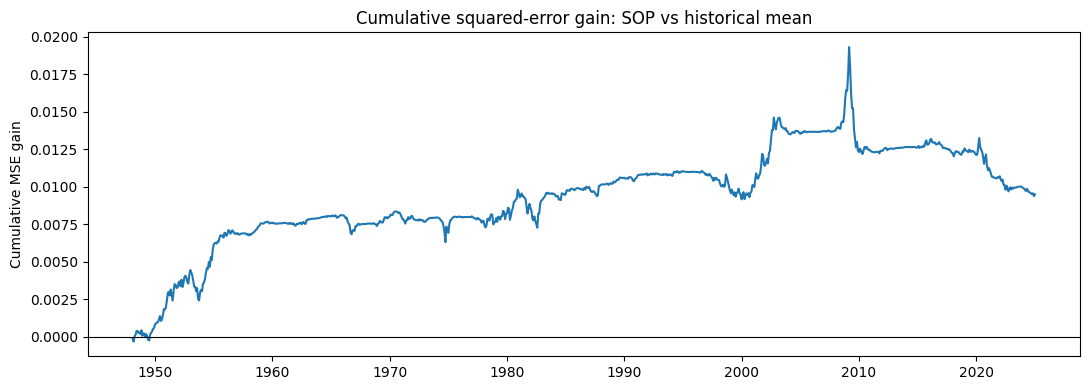

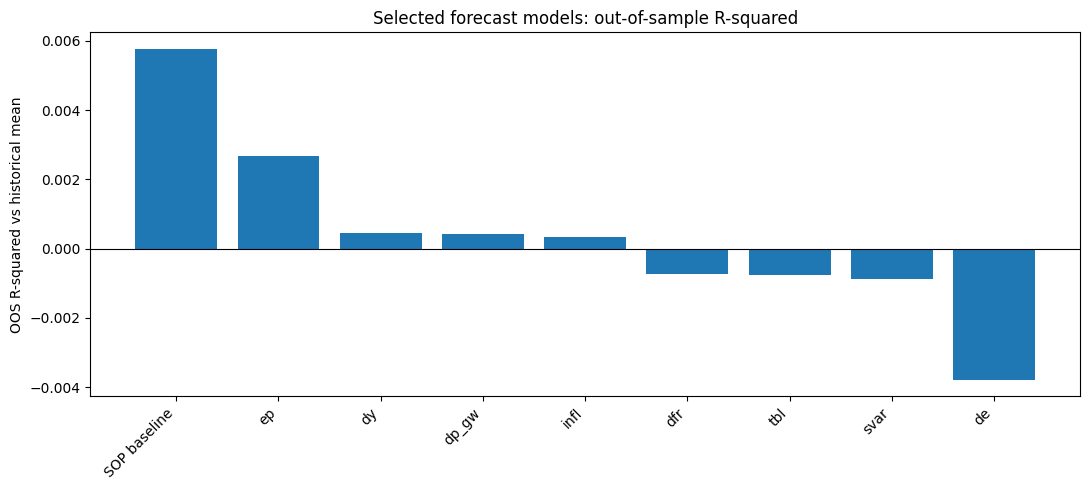

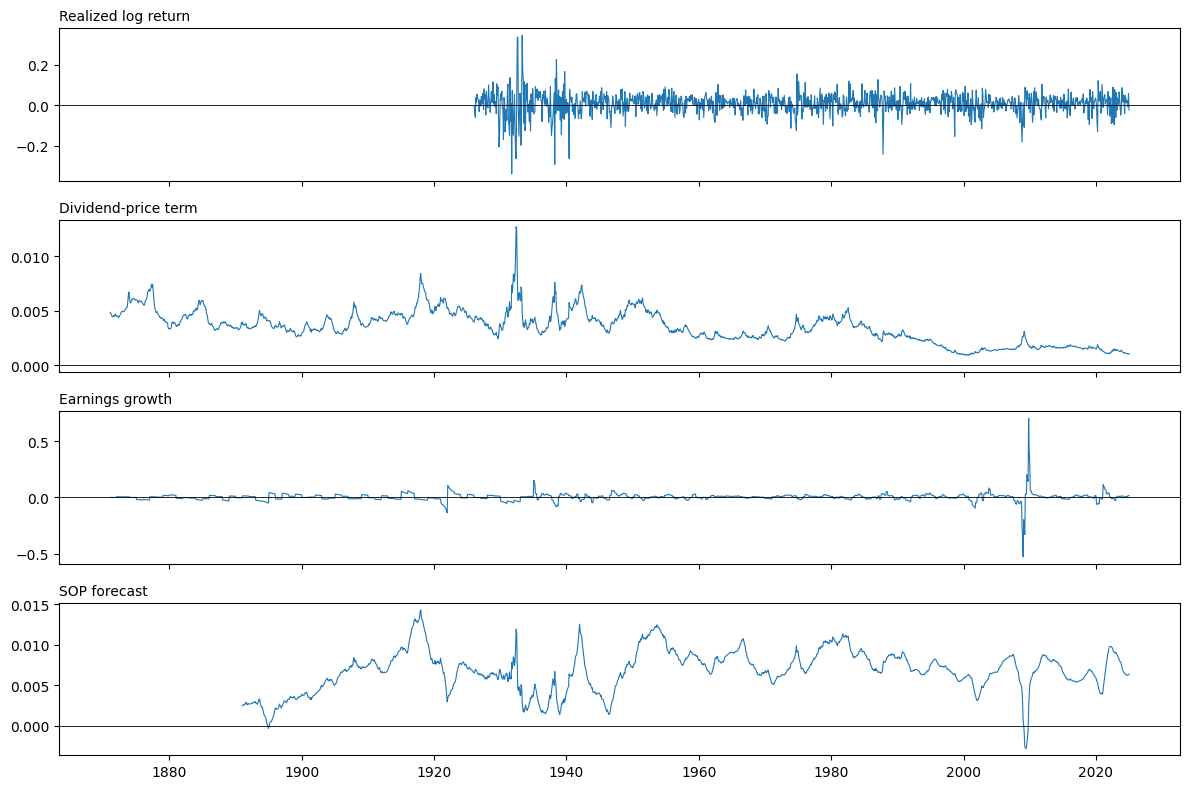

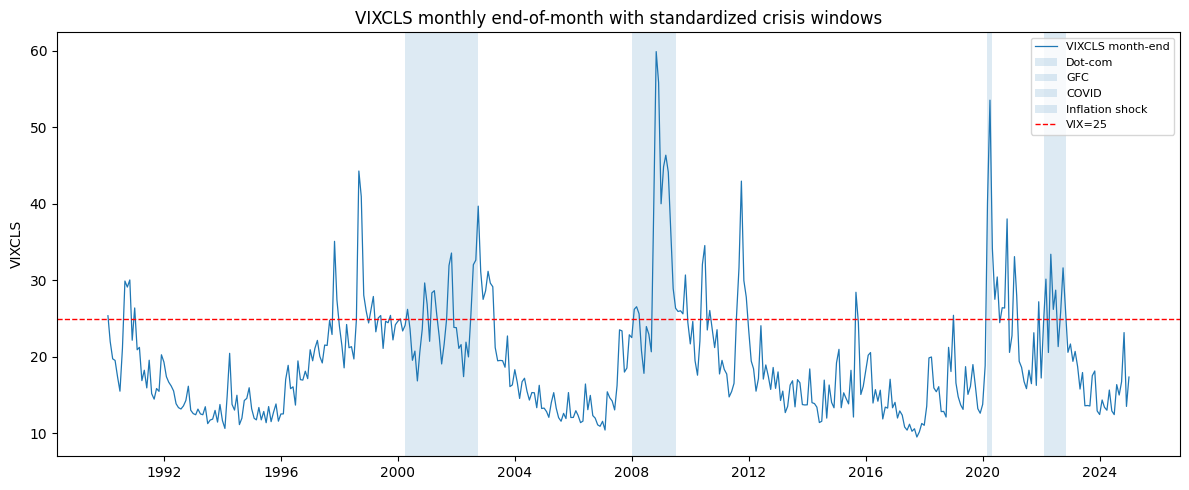

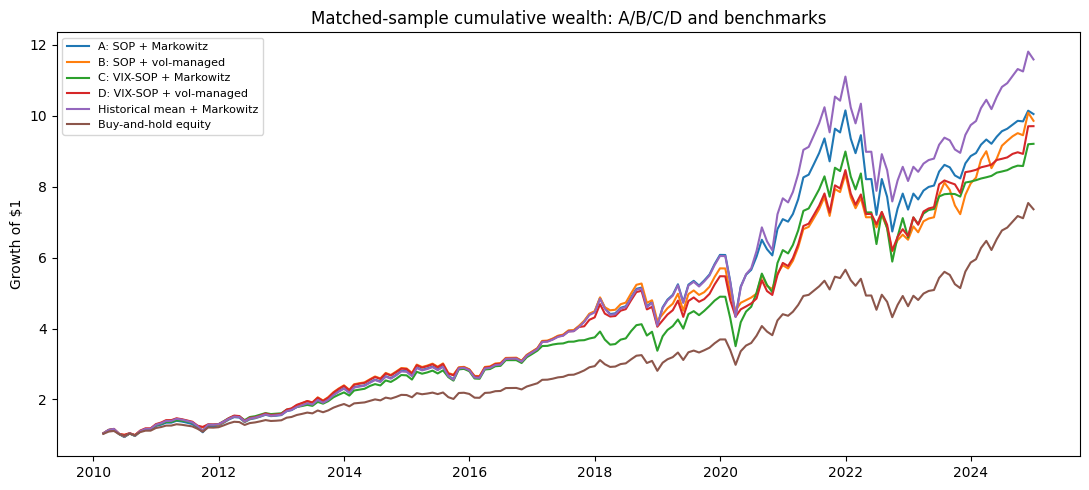

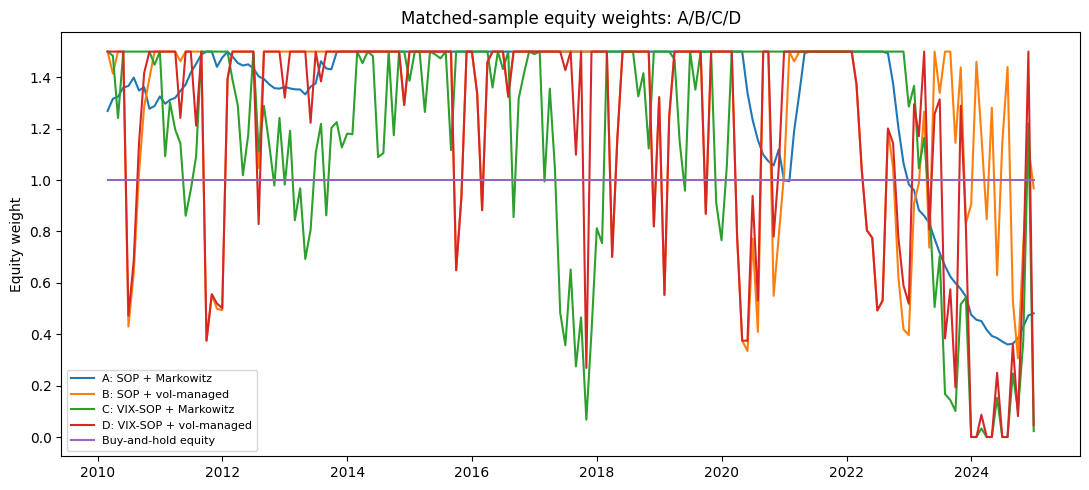

In [22]:
# =============================================================================
# Export last 12 months of forecasts for inspection
# =============================================================================
last12_cols = ["date", "forecast_target_date", "ret_lead", "hist_mean", "ms", "ms_enh_VIXCLS", "ms_enh_dfy", "ms_enh_ntis", "ms_lagfund", "ms_winsor"]
last12 = vix_df.sort_values("date").tail(12)[[c for c in last12_cols if c in vix_df.columns]]  # last 12 months
last12.to_csv(OUT / add_suffix("sop_last12_forecasts.csv"), index=False)
display(last12)

# =============================================================================
# Figure: Cumulative MSE gain of SOP over historical mean
# =============================================================================
# Positive values = SOP has lower squared error than historical mean (SOP wins)
plot_data = eval_base.dropna(subset=["ret_lead", "ms", "hist_mean"]).copy()
# MSE gain = MSE(HM) - MSE(SOP), positive means SOP is better
plot_data["cum_mse_gain"] = ((plot_data["ret_lead"] - plot_data["hist_mean"]) ** 2 - ( plot_data["ret_lead"] - plot_data["ms"]) ** 2).cumsum()
plt.figure(figsize=(11, 4))
plt.plot(plot_data["forecast_target_date"], plot_data["cum_mse_gain"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Cumulative squared-error gain: SOP vs historical mean")
plt.ylabel("Cumulative MSE gain")
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_cum_mse_gain.png"), dpi=200)
plt.show()

# =============================================================================
# Figure: OOS R-squared for top/bottom 5 benchmark predictors
# =============================================================================
bar = bench_table.dropna(subset=["OOS_R2_vs_HM"]).copy()
bar = pd.concat([bar.head(5), bar.tail(5)]).drop_duplicates("model")  # top 5 and bottom 5 by OOS R2
plt.figure(figsize=(11, 5))
plt.bar(bar["model"], bar["OOS_R2_vs_HM"])
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.title("Selected forecast models: out-of-sample R-squared")
plt.ylabel("OOS R-squared vs historical mean")
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_oos_r2_comparison.png"), dpi=200)
plt.show()

# =============================================================================
# Figure: Time series of SOP components
# =============================================================================
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, col, title in zip(axes, ["r_log", "dp", "ge", "ms"], ["Realized log return", "Dividend-price term", "Earnings growth", "SOP forecast"]):
    ax.plot(df["date"], df[col], linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(title, loc="left", fontsize=10)
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_sop_components.png"), dpi=200)
plt.show()

# =============================================================================
# Figure: VIX time series with crisis windows
# =============================================================================
vix_plot = df.dropna(subset=["VIXCLS"]).copy()
if len(vix_plot):
    plt.figure(figsize=(12, 5))
    plt.plot(vix_plot["date"], vix_plot["VIXCLS"], linewidth=0.9, label="VIXCLS month-end")
    for name, (start, end) in CRISIS_WINDOWS.items():
        plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, label=name)  # shade crisis windows
    plt.axhline(25, color="red", linestyle="--", linewidth=1, label="VIX=25")  # VIX>25 threshold
    plt.title("VIXCLS monthly end-of-month with standardized crisis windows")
    plt.ylabel("VIXCLS")
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT / add_suffix("vix_crisis_chart.png"), dpi=200)
    plt.show()

# =============================================================================
# Figure: Cumulative wealth for all strategies (matched sample)
# =============================================================================
plt.figure(figsize=(11, 5))
for label, (ret_col, _) in strategy_map.items():
    wealth = (1 + matched[ret_col]).cumprod()  # compound growth of $1
    plt.plot(matched["forecast_target_date"], wealth, label=label)
plt.title("Matched-sample cumulative wealth: A/B/C/D and benchmarks")
plt.ylabel("Growth of $1")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_strategy_cum_wealth_matched.png"), dpi=200)
plt.show()

# =============================================================================
# Figure: Equity weights over time for A/B/C/D strategies
# =============================================================================
plt.figure(figsize=(11, 5))
for label, (_, weight_col) in strategy_map.items():
    if label.startswith(("A", "B", "C", "D")):  # only SOP strategies, not benchmarks
        plt.plot(matched["forecast_target_date"], matched[weight_col], label=label)
plt.title("Matched-sample equity weights: A/B/C/D")
plt.ylabel("Equity weight")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_strategy_weights_matched.png"), dpi=200)
plt.show()